#Metapopulation Dynamics on Networks: Synchrony, Collapse, and Topology
#An Exploration of Coupled Modified Ricker Maps as a Complex System


The local map governing each node in our system is:
xn+1=xn2exp⁡(r−xn)x_{n+1} = x_n^2 \exp(r - x_n)xn+1​=xn2​exp(r−xn​)
This is a modified Ricker map — a classic model from theoretical ecology used to describe the discrete-time growth of a population. The standard Ricker map uses xnexp⁡(r−xn)x_n \exp(r - x_n)
xn​exp(r−xn​), but the xn2x_n^2
xn2​ term here introduces a stronger Allee effect: populations that fall too low struggle to recover, making the dynamics richer and more sensitive to perturbations. The parameter r∈[1,3]r \in [1, 3]
r∈[1,3] controls the intrinsic growth rate, and x>0x > 0
x>0 represents population density.




I explores the system in three progressively complex layers:


**Part A — Local Map Analysis: first fully characterize the single-node dynamics: fixed points, their stability, the bifurcation structure as rr
r varies from 1 to 3, and the Lyapunov exponent to identify regions of stable, periodic, and chaotic behavior.**


**Part B — Two Coupled Maps: introduce diffusive coupling between two nodes and study how coupling strength ε\varepsilon
ε drives synchronization, suppresses chaos, and creates new collective behaviors absent in the isolated map.**


**Part C — Network of N Coupled Maps (Metapopulation Model):embed
N nodes on four network topologies — Ring, Small-World, Random, and Scale-Free — and couple them via migration. The central question is: *does the topology of dispersal routes determine whether subpopulations synchronize (and thus risk simultaneous collapse) or maintain asynchrony (ecological insurance)?* We measure synchronization error, compute Lyapunov spectra, and identify chimera-like states where parts of the network synchronize while others remain chaotic.
The coupling rule used throughout is the standard Coupled Map Lattice (CML) formulation:
xn+1(i)=f(xn(i))+ε∑jAij[f(xn(j))−f(xn(i))]x_{n+1}^{(i)} = f(x_n^{(i)}) + \varepsilon \sum_{j} A_{ij} \left[ f(x_n^{(j)}) - f(x_n^{(i)}) \right]xn+1(i)​=f(xn(i)​)+εj∑​Aij​[f(xn(j)​)−f(xn(i)​)]
where f(x)=x2er−xf(x) = x^2 e^{r-x}
f(x)=x2er−x, AijA_{ij}
Aij​ is the adjacency matrix of the network, and ε\varepsilon
ε is coupling strength. The local dynamics at every node remain exactly xn+1=xn2exp⁡(r−xn)x_{n+1} = x_n^2 \exp(r - x_n)
xn+1​=xn2​exp(r−xn​), satisfying the problem constraint.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'lines.linewidth': 1.5,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.facecolor': 'white'
})

print("All libraries loaded successfully.")
print("Modified Ricker Map: x_{n+1} = x_n^2 * exp(r - x_n)")

All libraries loaded successfully.
Modified Ricker Map: x_{n+1} = x_n^2 * exp(r - x_n)


# BLOCK 2: Define the local map f(x) and its derivative f'(x)
# f(x)  = x^2 * exp(r - x)       [the map itself]
# f'(x) = x * exp(r - x) * (2-x) [needed for stability & Lyapunov]


In [2]:
def f(x, r):
    """Local modified Ricker map: x_{n+1} = x^2 * exp(r - x)"""
    return x**2 * np.exp(r - x)

def df(x, r):
    """Derivative of local map: df/dx = x * exp(r-x) * (2 - x)"""
    return x * np.exp(r - x) * (2 - x)

def iterate_map(x0, r, n_steps):
    """Iterate the local map n_steps times from initial condition x0."""
    trajectory = np.zeros(n_steps)
    trajectory[0] = x0
    for n in range(1, n_steps):
        trajectory[n] = f(trajectory[n-1], r)
        # Guard against blow-up (population explosion or extinction)
        if not np.isfinite(trajectory[n]) or trajectory[n] < 1e-15:
            trajectory[n:] = np.nan
            break
    return trajectory

# Quick sanity check
r_test = 2.0
x_test = 1.5
print(f"Test: f({x_test}, r={r_test}) = {f(x_test, r_test):.4f}")
print(f"Test: f'({x_test}, r={r_test}) = {df(x_test, r_test):.4f}")

Test: f(1.5, r=2.0) = 3.7096
Test: f'(1.5, r=2.0) = 1.2365



# BLOCK 3: Fixed Point Analysis
# Non-trivial fixed point satisfies: 1 = x* exp(r - x*)
# solve this numerically for each r and check |f'(x*)| < 1
# Trivial fixed point x*=0 is always unstable for r>0



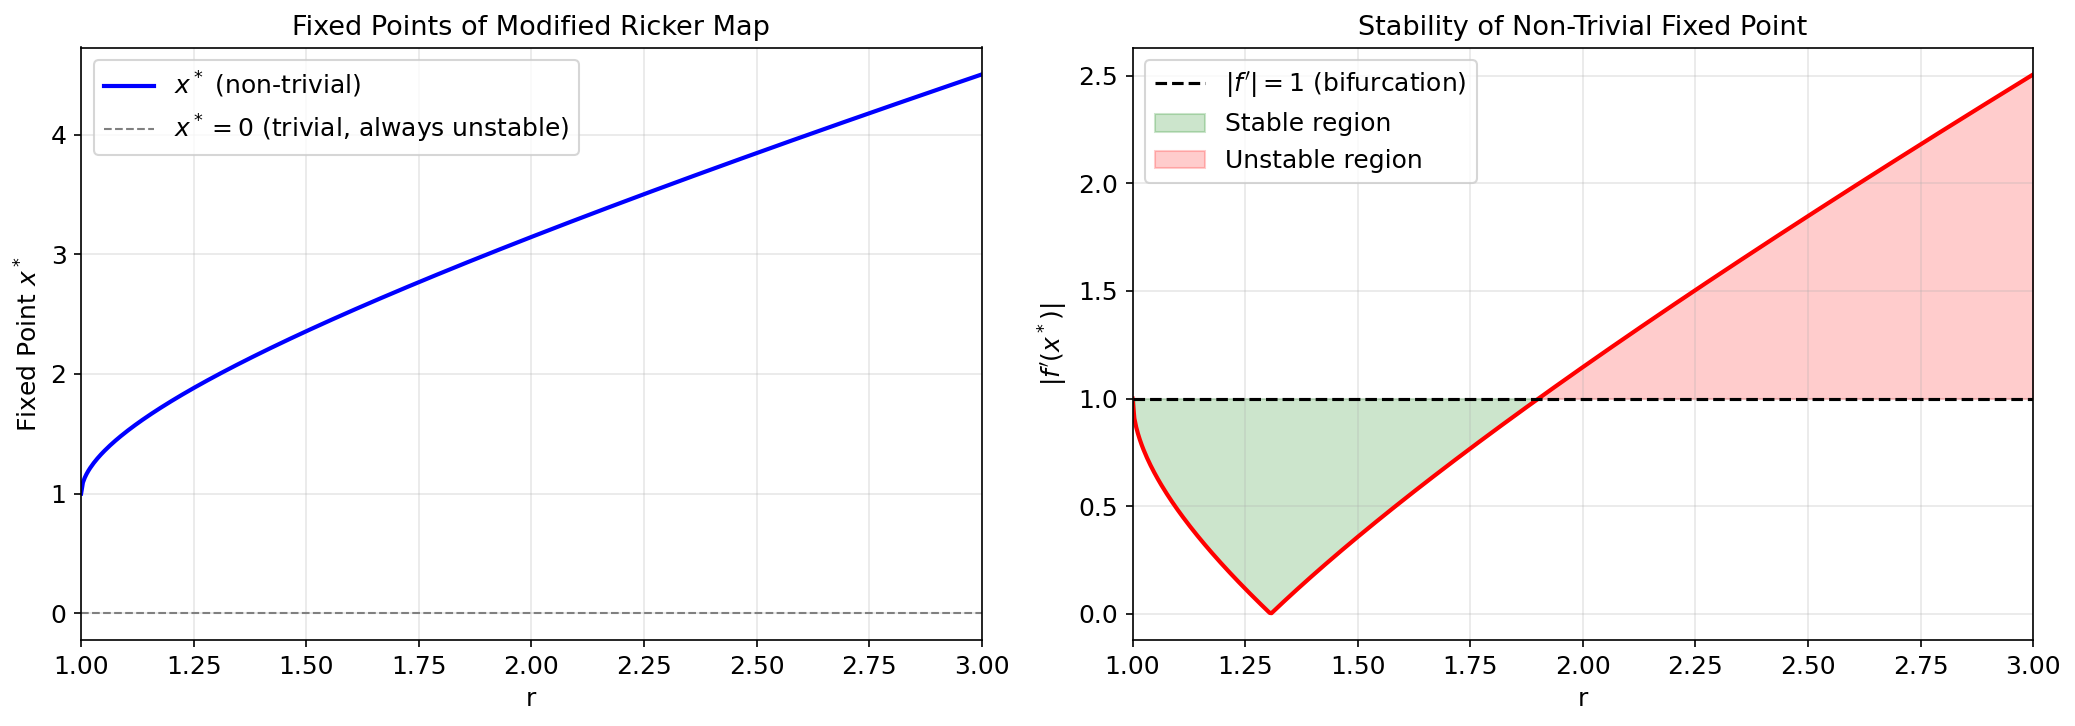


Fixed point loses stability at r ≈ 1.902
At r=2.0: x* = 3.1462, |f'(x*)| = 1.1462


In [4]:
from scipy.optimize import brentq

def find_nontrivial_fixed_point(r):
    """
    Find non-trivial fixed point: x* such that x* = x*^2 * exp(r - x*)
    Simplifies to: x* * exp(r - x*) = 1
    Rearranged: g(x) = x*exp(r-x) - 1 = 0
    """
    g = lambda x: x * np.exp(r - x) - 1
    try:
        if np.isclose(r, 1.0): # Special case for r=1, where x*=1 is the fixed point
            return 1.0
        # For r > 1, g(1.0) = exp(r-1) - 1 > 0, and g(r+3) is negative,
        # correctly bracketing the larger non-trivial root.
        x_star = brentq(g, 1.0, r + 3)
        return x_star
    except ValueError: # Catch specific ValueError from brentq if no root is found or bounds are bad
        return None
    except Exception as e:
        # print(f"Error finding fixed point for r={r}: {e}") # Uncomment for debugging
        return None

r_values = np.linspace(1.0, 3.0, 500)
fixed_points = []
stabilities = []

for r in r_values:
    xstar = find_nontrivial_fixed_point(r)
    if xstar is not None:
        fixed_points.append(xstar)
        slope = abs(df(xstar, r))
        stabilities.append(slope)
    else:
        fixed_points.append(np.nan)
        stabilities.append(np.nan)

fixed_points = np.array(fixed_points)
stabilities = np.array(stabilities)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot fixed point location
axes[0].plot(r_values, fixed_points, 'b-', linewidth=2, label=r'$x^*$ (non-trivial)')
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1, label=r'$x^*=0$ (trivial, always unstable)')
axes[0].set_xlabel('r')
axes[0].set_ylabel(r'Fixed Point $x^*$')
axes[0].set_title('Fixed Points of Modified Ricker Map')
axes[0].legend()
axes[0].set_xlim([1, 3])

# Plot |f'(x*)| — stability indicator
axes[1].plot(r_values, stabilities, 'r-', linewidth=2)
axes[1].axhline(1.0, color='k', linestyle='--', linewidth=1.5, label=r'$|f^\prime|=1$ (bifurcation)')
axes[1].fill_between(r_values, stabilities, 1.0,
                      where=(stabilities < 1), alpha=0.2, color='green', label='Stable region')
axes[1].fill_between(r_values, stabilities, 1.0,
                      where=(stabilities > 1), alpha=0.2, color='red', label='Unstable region')
axes[1].set_xlabel('r')
axes[1].set_ylabel(r"$|f'(x^*)|$")
axes[1].set_title('Stability of Non-Trivial Fixed Point')
axes[1].legend()
axes[1].set_xlim([1, 3])

plt.tight_layout()
plt.savefig('fixed_point_analysis.png', bbox_inches='tight')
plt.show()

# Print critical r where instability begins
unstable_indices = np.where(stabilities > 1)[0]
if unstable_indices.size > 0:
    critical_r_index = unstable_indices[0]
    critical_r = r_values[critical_r_index]
    print(f"\nFixed point loses stability at r \u2248 {critical_r:.3f}")
else:
    print("\nFixed point remains stable for all plotted r values (up to r=3.0) or could not be found.")

# Print information for r=2.0
x_star_at_r2 = find_nontrivial_fixed_point(2.0)
if x_star_at_r2 is not None:
    print(f"At r=2.0: x* = {x_star_at_r2:.4f}, |f'(x*)| = {abs(df(x_star_at_r2, 2.0)):.4f}")
else:
    print(f"Could not find fixed point for r=2.0.")



# BLOCK 4: Bifurcation Diagram
# For each value of r, we iterate the map for many steps,
# discard the transient (first 500 steps), and plot the
# remaining iterates. This reveals period-doubling route to chaos.


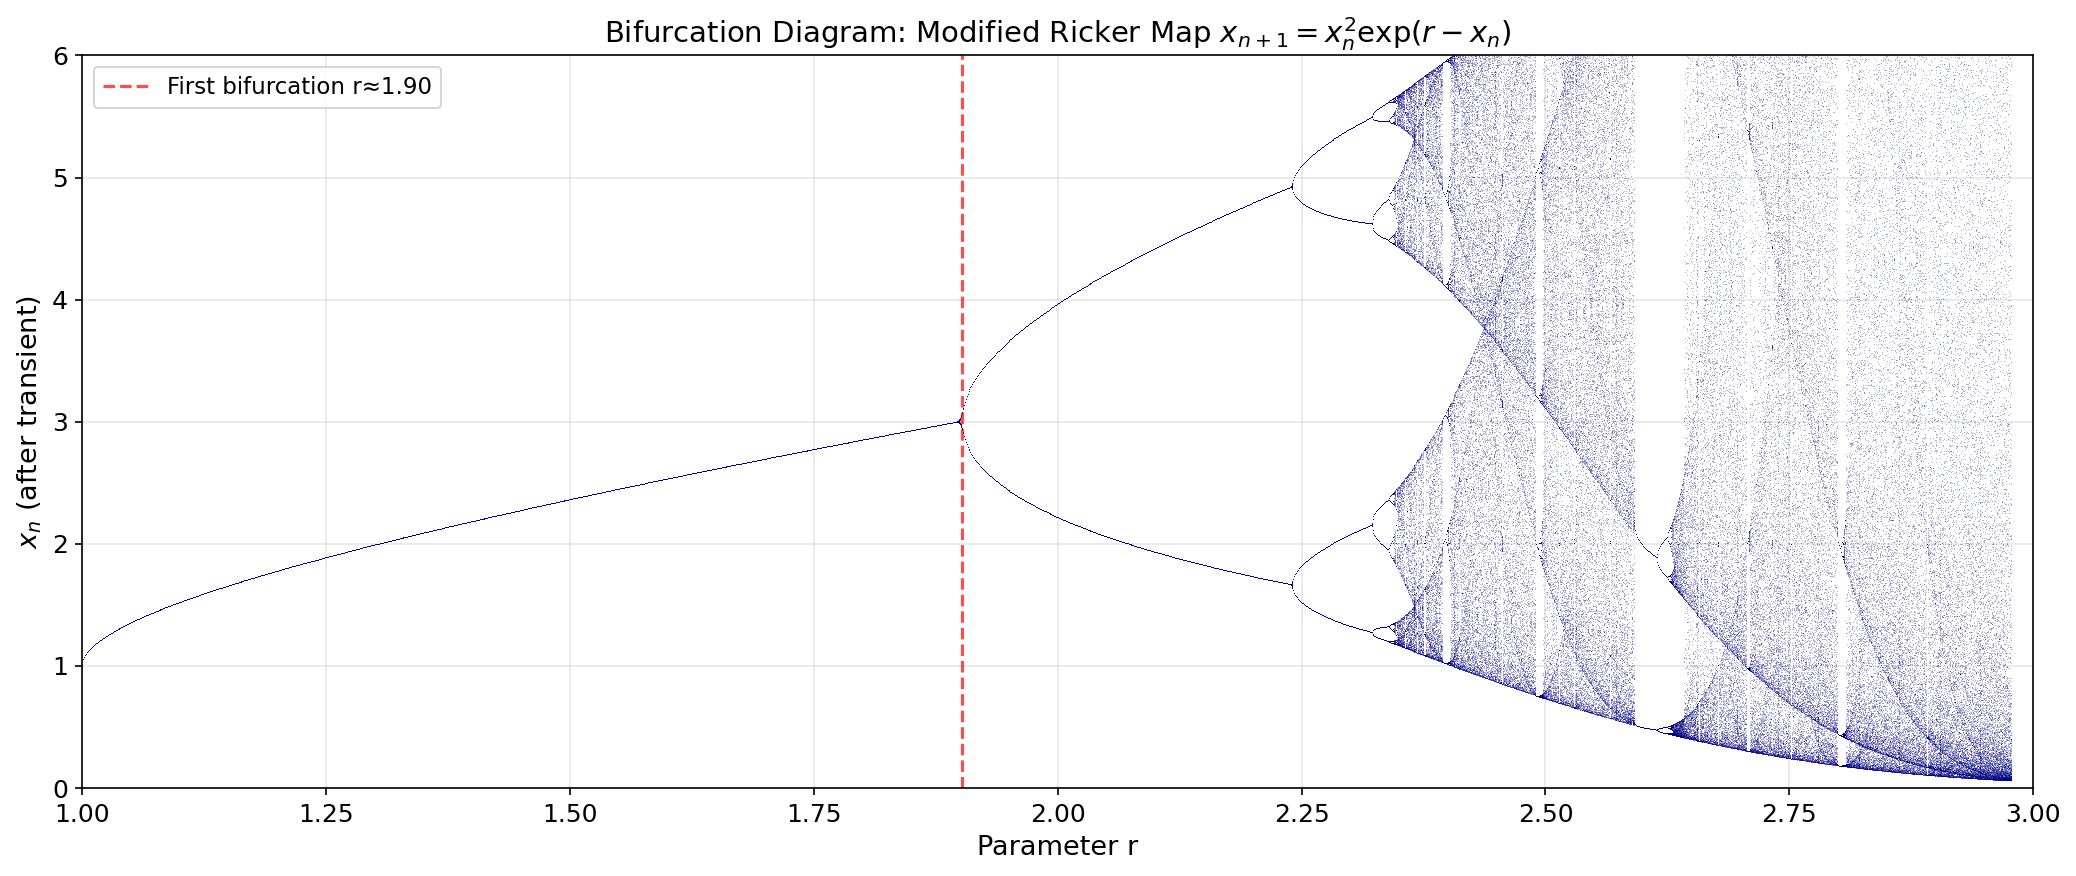

Bifurcation diagram saved.


In [5]:


r_values_bif = np.linspace(1.0, 3.0, 2000)
n_transient = 500
n_plot = 300
x0 = 1.5  # initial condition

fig, ax = plt.subplots(figsize=(14, 6))

for r in r_values_bif:
    traj = iterate_map(x0, r, n_transient + n_plot)
    attractor = traj[n_transient:]
    # Remove NaN values
    attractor = attractor[np.isfinite(attractor)]
    if len(attractor) > 0:
        ax.plot([r] * len(attractor), attractor, ',',
                color='navy', alpha=0.3, markersize=0.5)

ax.set_xlabel('Parameter r', fontsize=13)
ax.set_ylabel(r'$x_n$ (after transient)', fontsize=13)
ax.set_title('Bifurcation Diagram: Modified Ricker Map $x_{n+1} = x_n^2 \exp(r - x_n)$', fontsize=14)
ax.set_xlim([1, 3])
ax.set_ylim([0, 6])

# Annotate key regions
ax.axvline(critical_r, color='red', linestyle='--', alpha=0.7, label=f'First bifurcation r≈{critical_r:.2f}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('bifurcation_diagram.png', bbox_inches='tight')
plt.show()
print("Bifurcation diagram saved.")


# BLOCK 5: Lyapunov Exponent Spectrum
# lambda = (1/N) * sum of log|f'(x_n)|
# lambda > 0 → chaos, lambda < 0 → stable, lambda = 0 → bifurcation point
# This tells us EXACTLY where chaos lives in parameter space.


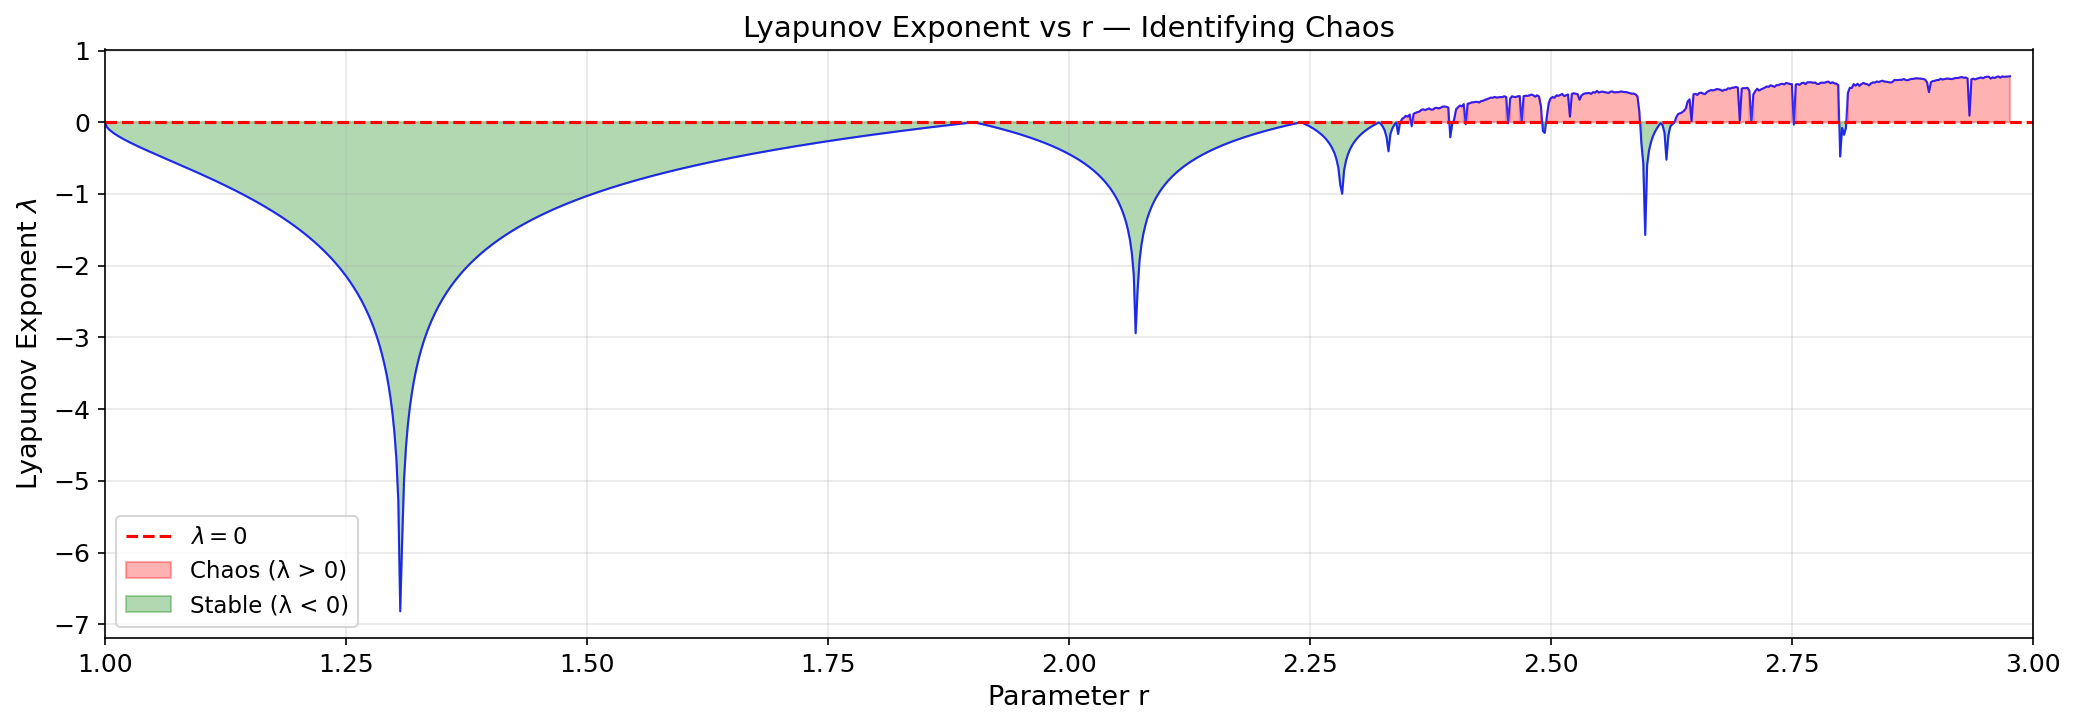

Chaos first appears at r ≈ 2.345
Max Lyapunov exponent: 0.6414 at r = 2.976


In [6]:


def lyapunov_exponent(r, x0=1.5, n_steps=5000, n_transient=500):
    """Compute Lyapunov exponent for given r."""
    x = x0
    # Run transient
    for _ in range(n_transient):
        x = f(x, r)
        if not np.isfinite(x) or x < 1e-15:
            return np.nan

    # Accumulate log|f'(x)|
    lyap_sum = 0.0
    count = 0
    for _ in range(n_steps):
        deriv = abs(df(x, r))
        if deriv > 1e-15:
            lyap_sum += np.log(deriv)
            count += 1
        x = f(x, r)
        if not np.isfinite(x) or x < 1e-15:
            break

    return lyap_sum / count if count > 0 else np.nan

r_values_lyap = np.linspace(1.0, 3.0, 1000)
lyap_exponents = np.array([lyapunov_exponent(r) for r in r_values_lyap])

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(r_values_lyap, lyap_exponents, 'b-', linewidth=1, alpha=0.8)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label=r'$\lambda = 0$')
ax.fill_between(r_values_lyap, lyap_exponents, 0,
                where=(lyap_exponents > 0), alpha=0.3, color='red', label='Chaos (λ > 0)')
ax.fill_between(r_values_lyap, lyap_exponents, 0,
                where=(lyap_exponents < 0), alpha=0.3, color='green', label='Stable (λ < 0)')

ax.set_xlabel('Parameter r', fontsize=13)
ax.set_ylabel(r'Lyapunov Exponent $\lambda$', fontsize=13)
ax.set_title('Lyapunov Exponent vs r — Identifying Chaos', fontsize=14)
ax.set_xlim([1, 3])
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('lyapunov_exponent.png', bbox_inches='tight')
plt.show()

# Summarize
chaos_onset = r_values_lyap[np.where(lyap_exponents > 0.01)[0]]
if len(chaos_onset) > 0:
    print(f"Chaos first appears at r ≈ {chaos_onset[0]:.3f}")
print(f"Max Lyapunov exponent: {np.nanmax(lyap_exponents):.4f} at r = {r_values_lyap[np.nanargmax(lyap_exponents)]:.3f}")

# BLOCK 6: Two Coupled Maps
# System: two nodes i=1,2 coupled diffusively
# x1_{n+1} = f(x1) + eps*(f(x2) - f(x1))
# x2_{n+1} = f(x2) + eps*(f(x1) - f(x2))
# study how coupling strength eps drives synchronization.
# Sync error E = <|x1 - x2|> over time



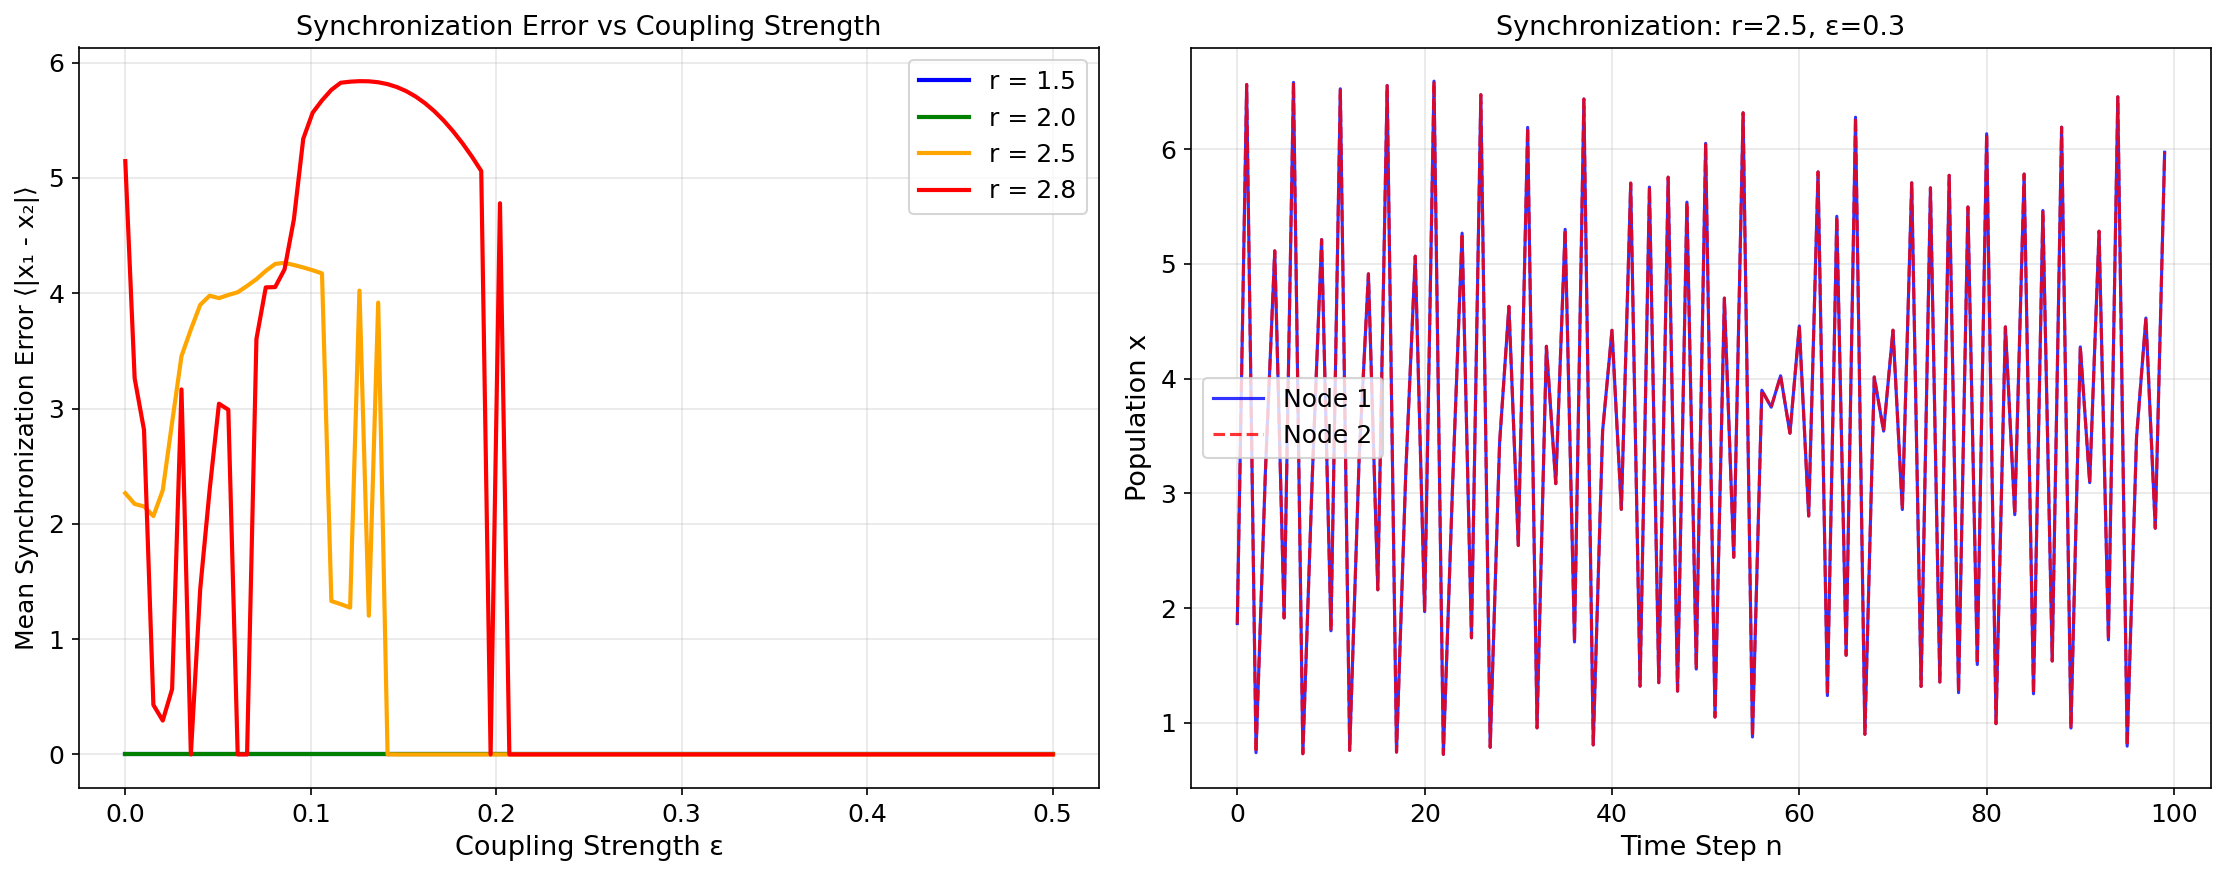

In [13]:
def two_coupled_maps(r, eps, x1_0, x2_0, n_steps=2000, n_transient=500):
    """Simulate two diffusively coupled modified Ricker maps."""
    x1, x2 = x1_0, x2_0
    sync_errors = []
    traj1, traj2 = [], []

    for n in range(n_steps + n_transient):
        f1, f2 = f(x1, r), f(x2, r)
        x1_new = f1 + eps * (f2 - f1)
        x2_new = f2 + eps * (f1 - f2)

        # Guard
        if not (np.isfinite(x1_new) and np.isfinite(x2_new)):
            break
        if x1_new < 1e-15 or x2_new < 1e-15:
            break

        x1, x2 = x1_new, x2_new

        if n >= n_transient:
            sync_errors.append(abs(x1 - x2))
            traj1.append(x1)
            traj2.append(x2)

    return np.array(traj1), np.array(traj2), np.array(sync_errors)

# Study sync error vs coupling strength for different r values
eps_values = np.linspace(0, 0.5, 100)
r_cases = [1.5, 2.0, 2.5, 2.8]
colors = ['blue', 'green', 'orange', 'red']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Sync error vs epsilon
for r_val, col in zip(r_cases, colors):
    mean_errors = []
    for eps in eps_values:
        _, _, errs = two_coupled_maps(r_val, eps, x1_0=1.2, x2_0=2.1)
        mean_errors.append(np.mean(errs) if len(errs) > 0 else np.nan)
    axes[0].plot(eps_values, mean_errors, color=col, label=f'r = {r_val}', linewidth=2)

axes[0].set_xlabel('Coupling Strength ε', fontsize=13)
axes[0].set_ylabel('Mean Synchronization Error ⟨|x₁ - x₂|⟩', fontsize=12)
axes[0].set_title('Synchronization Error vs Coupling Strength', fontsize=13)
axes[0].legend()

# Right: Time series showing sync at r=2.5, eps=0.3
r_demo, eps_demo = 2.5, 0.3
t1, t2, _ = two_coupled_maps(r_demo, eps_demo, x1_0=1.2, x2_0=2.5, n_steps=100, n_transient=200)
time_axis = np.arange(len(t1))
axes[1].plot(time_axis, t1, 'b-', label='Node 1', alpha=0.8)
axes[1].plot(time_axis, t2, 'r--', label='Node 2', alpha=0.8)
axes[1].set_xlabel('Time Step n', fontsize=13)
axes[1].set_ylabel('Population x', fontsize=13)
axes[1].set_title(f'Synchronization: r={r_demo}, ε={eps_demo}', fontsize=13)
axes[1].legend()

plt.tight_layout()
plt.savefig('two_coupled_maps.png', bbox_inches='tight')
plt.show()


# BLOCK 7: Construct the four network topologies
# compare how network structure affects collective dynamics.
# 1. Ring (1D lattice) — ordered, local connections
# 2. Small-World (Watts-Strogatz) — local + some long-range
# 3. Random (Erdos-Renyi) — random wiring
# 4. Scale-Free (Barabasi-Albert) — hubs dominate (most realistic)
# N=20 nodes, same average degree across all topologies


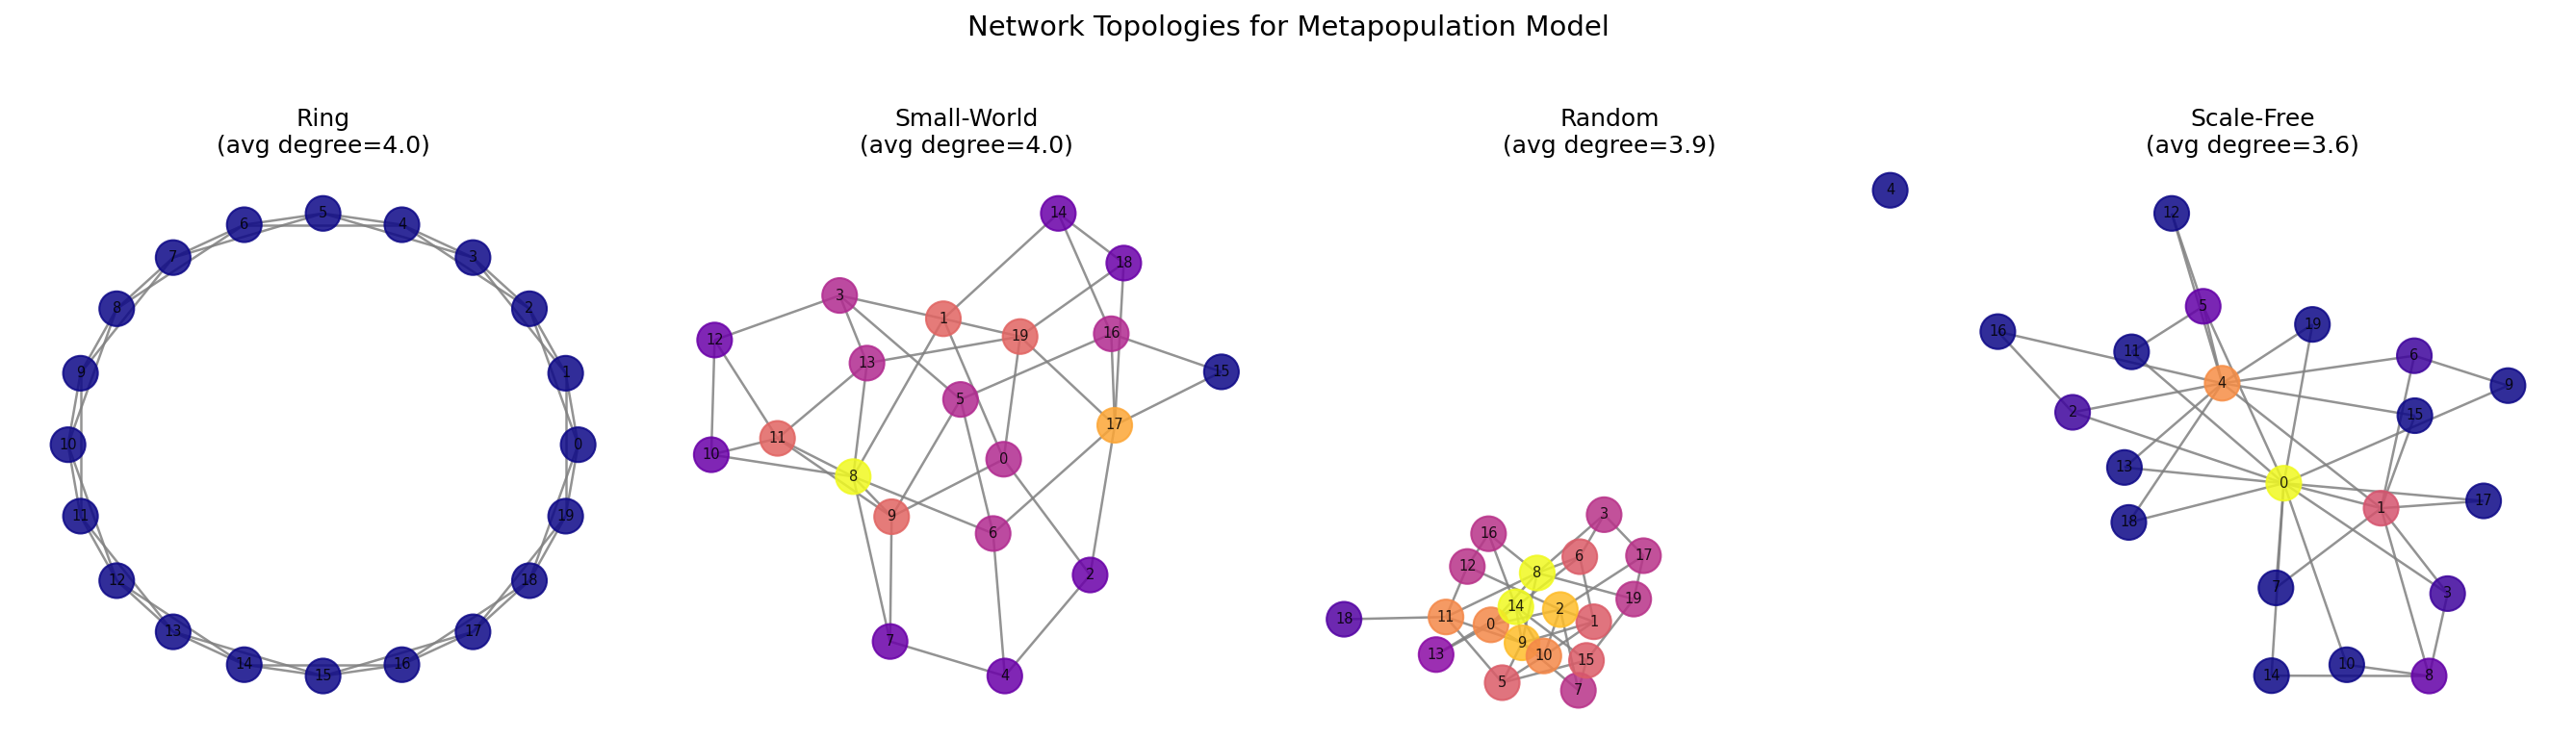

Network         Nodes    Edges    Avg Degree   Clustering   Avg Path
-----------------------------------------------------------------
Ring            20       40       4.00         0.500        2.895
Small-World     20       40       4.00         0.220        2.216
Random          20       39       3.90         0.155        nan
Scale-Free      20       36       3.60         0.409        1.974


In [7]:


N = 20  # number of nodes (patches)
np.random.seed(42)

# Build graphs
G_ring = nx.cycle_graph(N)
# Add next-nearest neighbors to ring for fair degree comparison
for i in range(N):
    G_ring.add_edge(i, (i+2) % N)

G_smallworld = nx.watts_strogatz_graph(N, k=4, p=0.3, seed=42)
G_random = nx.erdos_renyi_graph(N, p=0.21, seed=42)
G_scalefree = nx.barabasi_albert_graph(N, m=2, seed=42)

networks = {
    'Ring': G_ring,
    'Small-World': G_smallworld,
    'Random': G_random,
    'Scale-Free': G_scalefree
}

# Visualize all four topologies
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
pos_funcs = [
    nx.circular_layout,
    nx.spring_layout,
    nx.spring_layout,
    nx.spring_layout
]

for ax, (name, G), pos_func in zip(axes, networks.items(), pos_funcs):
    pos = pos_func(G, seed=42) if name != 'Ring' else nx.circular_layout(G)
    degrees = dict(G.degree())
    node_colors = [degrees[n] for n in G.nodes()]
    nx.draw(G, pos, ax=ax, node_color=node_colors, cmap='plasma',
            node_size=300, with_labels=True, font_size=7,
            edge_color='gray', alpha=0.85, width=1.2)
    ax.set_title(f'{name}\n(avg degree={2*G.number_of_edges()/N:.1f})', fontsize=12)

plt.suptitle('Network Topologies for Metapopulation Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('network_topologies.png', bbox_inches='tight')
plt.show()

# Print network statistics
print(f"{'Network':<15} {'Nodes':<8} {'Edges':<8} {'Avg Degree':<12} {'Clustering':<12} {'Avg Path'}")
print("-"*65)
for name, G in networks.items():
    avg_deg = 2*G.number_of_edges()/N
    clustering = nx.average_clustering(G)
    try:
        avg_path = nx.average_shortest_path_length(G)
    except:
        avg_path = float('nan')
    print(f"{name:<15} {N:<8} {G.number_of_edges():<8} {avg_deg:<12.2f} {clustering:<12.3f} {avg_path:.3f}")


# BLOCK 8: Coupled Map Lattice (CML) on Networks
# Full simulation of N nodes on each network topology.
# Equation: x_i(n+1) = f(x_i) + eps * sum_j A_ij [f(x_j) - f(x_i)]
# compute synchronization error and full spatiotemporal dynamics.


In [8]:


def simulate_cml(G, r, eps, x0_array, n_steps=1000, n_transient=500):
    """
    Simulate Coupled Map Lattice on network G.
    Returns full trajectory and synchronization error time series.
    """
    N = len(G.nodes())
    A = nx.to_numpy_array(G)  # Adjacency matrix
    x = x0_array.copy()

    trajectories = np.zeros((n_steps, N))
    sync_errors = np.zeros(n_steps)

    for step in range(n_transient + n_steps):
        fx = np.array([f(x[i], r) for i in range(N)])

        # CML update: diffusive coupling
        x_new = np.zeros(N)
        for i in range(N):
            coupling = np.sum(A[i, :] * (fx - fx[i]))
            x_new[i] = fx[i] + eps * coupling

        # Guard: keep positive
        x_new = np.where(x_new > 1e-15, x_new, 1e-10)
        x_new = np.where(np.isfinite(x_new), x_new, x)
        x = x_new

        if step >= n_transient:
            idx = step - n_transient
            trajectories[idx] = x
            sync_errors[idx] = np.std(x)  # std across nodes = sync measure

    return trajectories, sync_errors

# Set parameters
r = 2.5
eps = 0.15
np.random.seed(7)
x0 = np.random.uniform(0.5, 3.0, N)  # random initial conditions

results = {}
for name, G in networks.items():
    traj, sync_err = simulate_cml(G, r, eps, x0, n_steps=500, n_transient=300)
    results[name] = {'traj': traj, 'sync_err': sync_err}
    print(f"{name}: Final sync error (std) = {np.mean(sync_err[-100:]):.4f}")

Ring: Final sync error (std) = 1.6528
Small-World: Final sync error (std) = 1.8353
Random: Final sync error (std) = 1.0706
Scale-Free: Final sync error (std) = 1.6574



# BLOCK 9: Spatiotemporal Diagrams
# Each row = one time step, each column = one node (patch)
# Color = population value x_i(n)
# These reveal synchronized vs asynchronous collective behavior
# visually — the signature visualization of coupled map lattices.



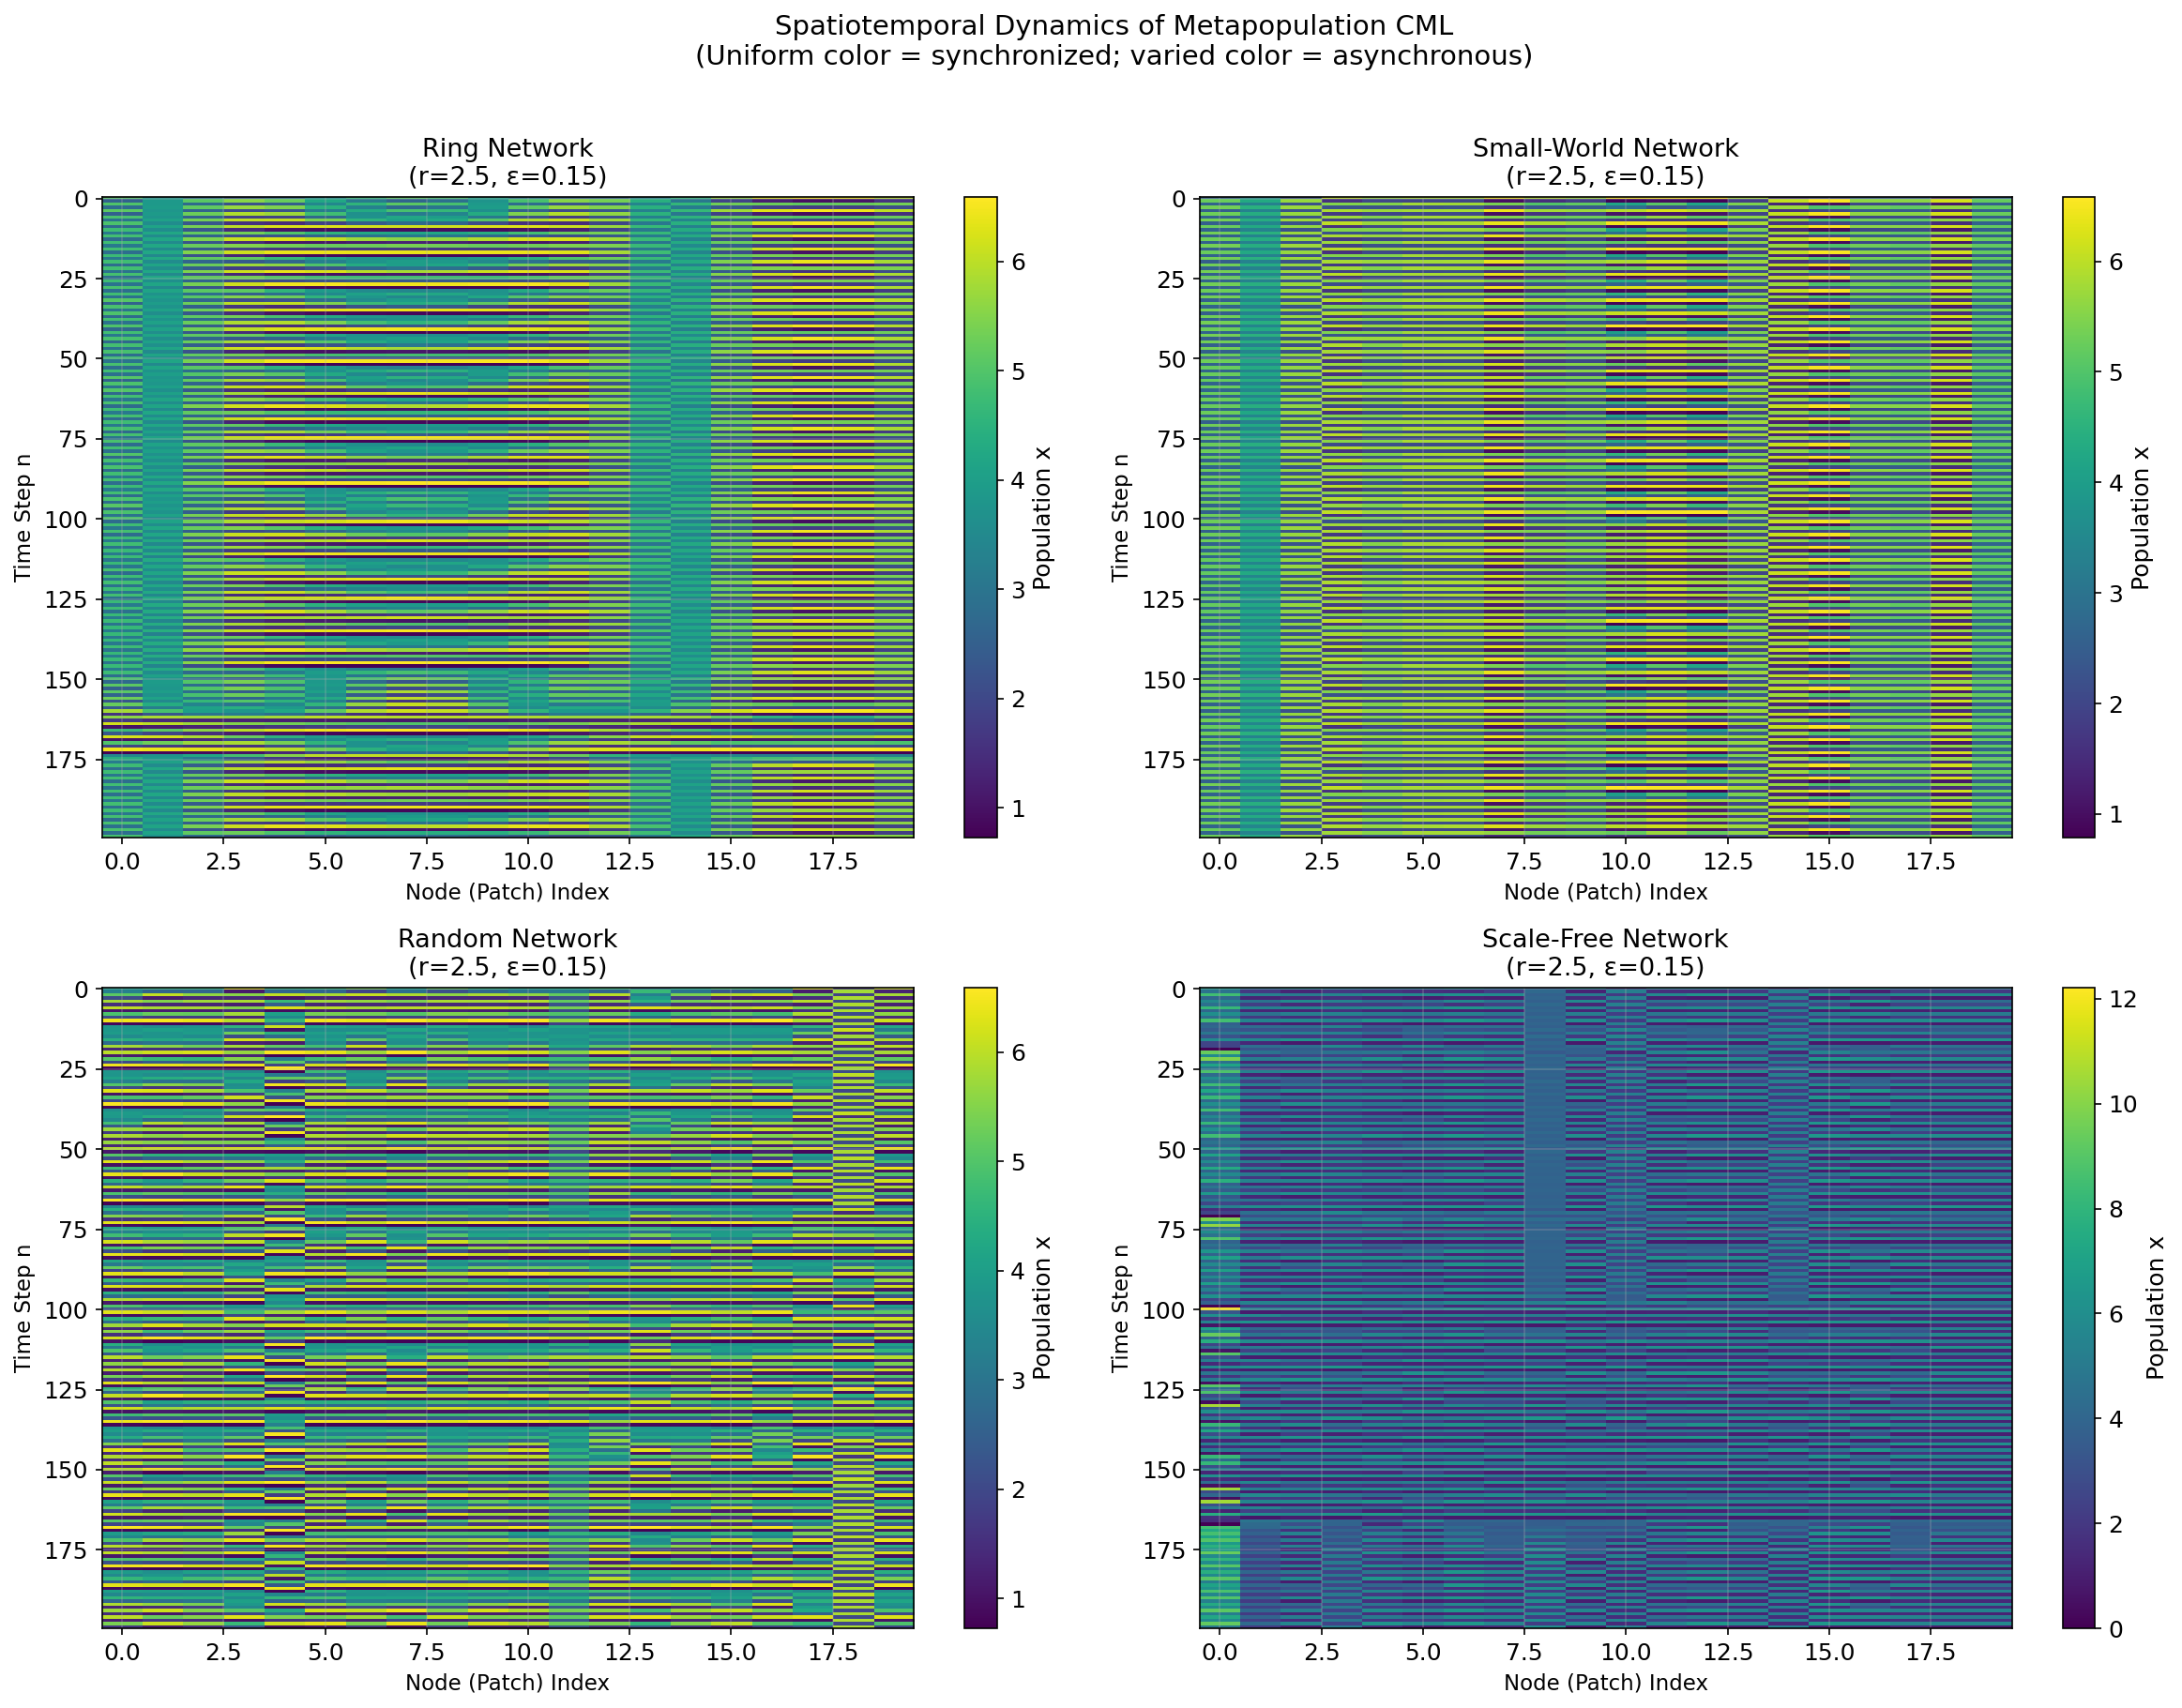

In [9]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

cmap = plt.cm.viridis

for ax, (name, res) in zip(axes, results.items()):
    traj = res['traj'][:200, :]  # show first 200 steps
    im = ax.imshow(traj, aspect='auto', cmap=cmap,
                   origin='upper', interpolation='nearest')
    ax.set_title(f'{name} Network\n(r={r}, ε={eps})', fontsize=13)
    ax.set_xlabel('Node (Patch) Index', fontsize=11)
    ax.set_ylabel('Time Step n', fontsize=11)
    plt.colorbar(im, ax=ax, label='Population x')

plt.suptitle('Spatiotemporal Dynamics of Metapopulation CML\n'
             '(Uniform color = synchronized; varied color = asynchronous)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('spatiotemporal_dynamics.png', bbox_inches='tight')
plt.show()


# BLOCK 10: Core Result — Topology vs Synchronization
# For each network, sweep coupling strength eps from 0 to 0.5
# and measure mean synchronization error.

# Lower error = more synchronized = higher extinction risk.


Sweeping ε for Ring...
Sweeping ε for Small-World...
Sweeping ε for Random...
Sweeping ε for Scale-Free...


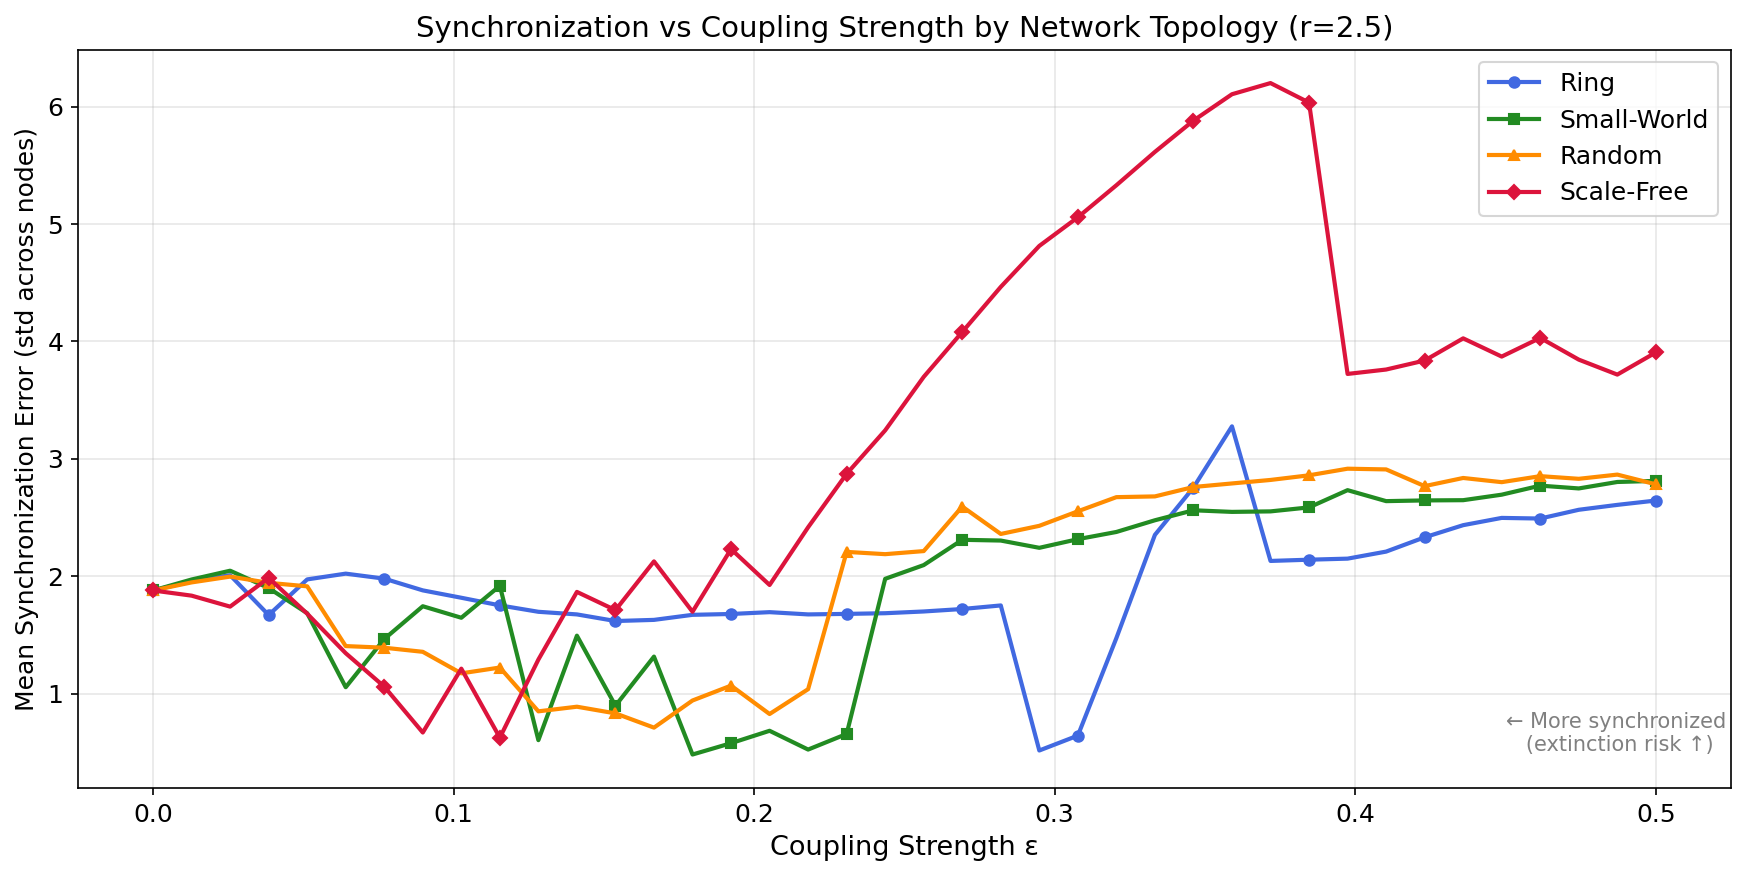


Key Result:
  Ring: sync error at ε=0.5 → 2.6456
  Small-World: sync error at ε=0.5 → 2.8130
  Random: sync error at ε=0.5 → 2.7838
  Scale-Free: sync error at ε=0.5 → 3.9067


In [10]:

eps_sweep = np.linspace(0.0, 0.5, 40)
r = 2.5
np.random.seed(42)
x0 = np.random.uniform(0.5, 3.0, N)

sync_results = {name: [] for name in networks}

for name, G in networks.items():
    print(f"Sweeping ε for {name}...")
    for eps_val in eps_sweep:
        _, sync_err = simulate_cml(G, r, eps_val, x0, n_steps=300, n_transient=300)
        sync_results[name].append(np.mean(sync_err[-100:]))

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
line_styles = ['-o', '-s', '-^', '-D']
colors_net = ['royalblue', 'forestgreen', 'darkorange', 'crimson']

for (name, vals), ls, col in zip(sync_results.items(), line_styles, colors_net):
    ax.plot(eps_sweep, vals, ls, color=col, label=name,
            markersize=5, linewidth=2, markevery=3)

ax.set_xlabel('Coupling Strength ε', fontsize=13)
ax.set_ylabel('Mean Synchronization Error (std across nodes)', fontsize=12)
ax.set_title(f'Synchronization vs Coupling Strength by Network Topology (r={r})', fontsize=14)
ax.legend(fontsize=12)

# Annotate interpretation
ax.annotate('← More synchronized\n   (extinction risk ↑)',
            xy=(0.45, 0.05), fontsize=10, color='gray',
            xycoords=('data', 'axes fraction'))

plt.tight_layout()
plt.savefig('sync_vs_coupling_topology.png', bbox_inches='tight')
plt.show()

print("\nKey Result:")
for name, vals in sync_results.items():
    print(f"  {name}: sync error at ε=0.5 → {vals[-1]:.4f}")


# BLOCK 11: How does chaos in the local map affect the network?
# fix topology (Scale-Free, most realistic) and eps=0.15,
# then sweep r from 1 to 3 to see if network coupling suppresses
# or amplifies chaos compared to the isolated local map.
# compare network Lyapunov exponent vs single-node Lyapunov.


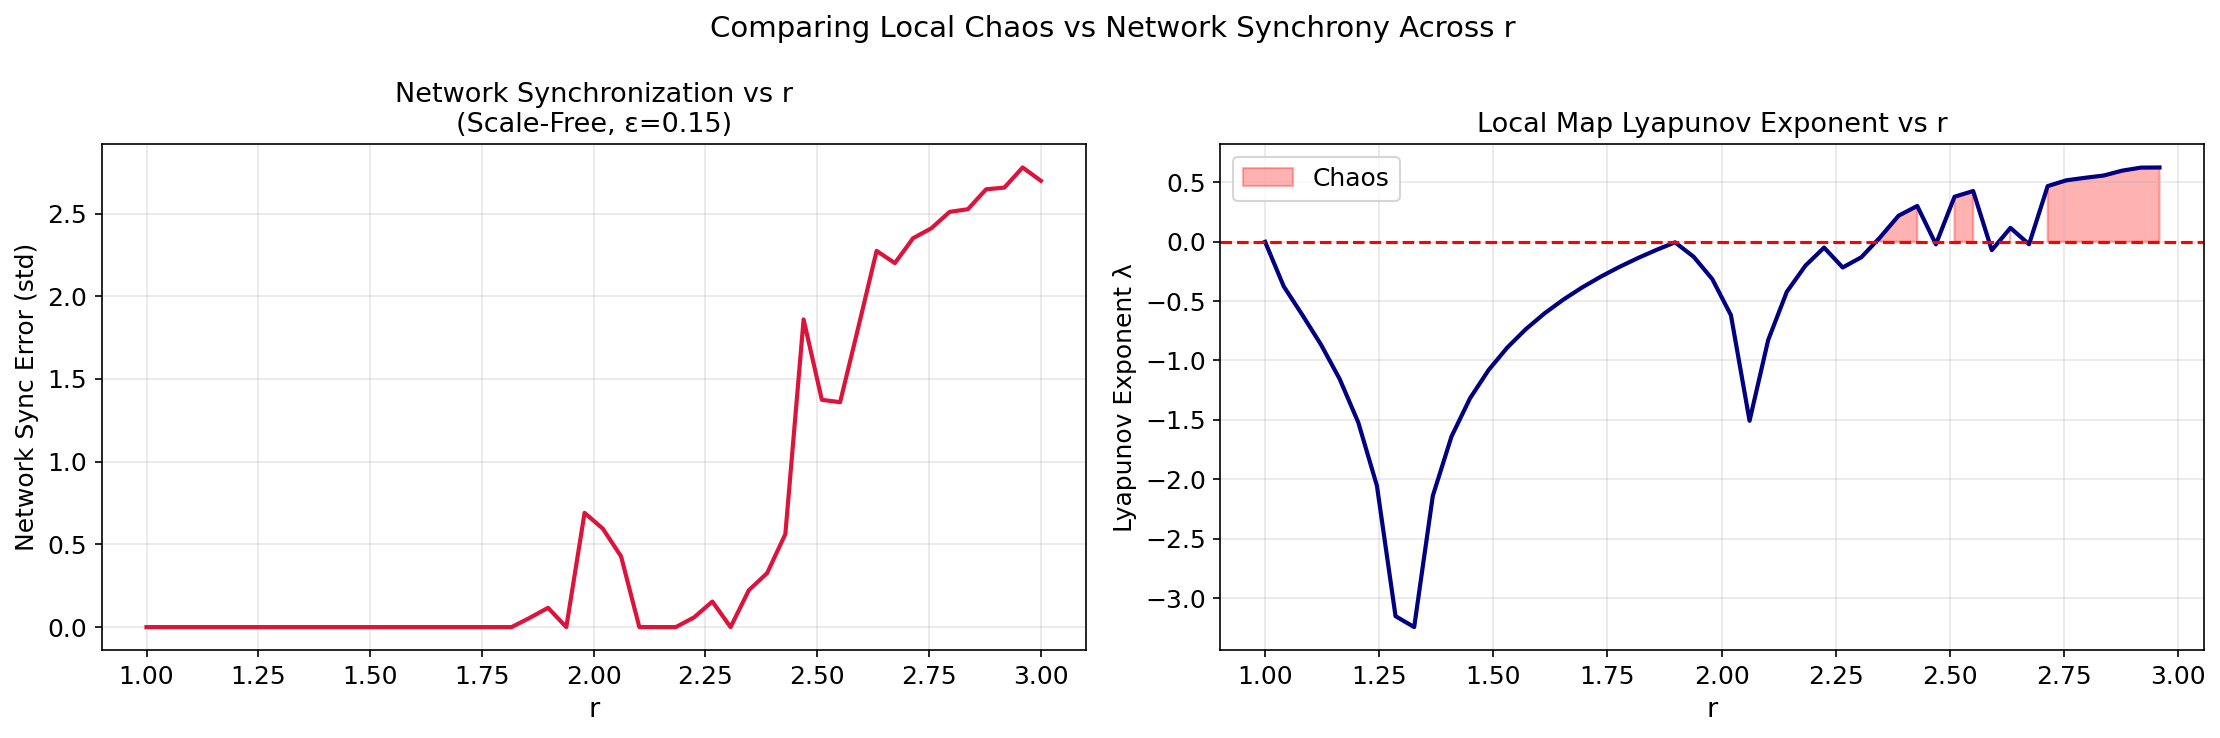

In [11]:


r_sweep = np.linspace(1.0, 3.0, 50)
eps_fixed = 0.15
G_sf = networks['Scale-Free']
np.random.seed(42)
x0 = np.random.uniform(0.5, 2.5, N)

network_sync_vs_r = []
local_lyap_vs_r = []

for r_val in r_sweep:
    # Network: measure sync error
    _, sync_err = simulate_cml(G_sf, r_val, eps_fixed, x0, n_steps=400, n_transient=400)
    network_sync_vs_r.append(np.mean(sync_err[-100:]))

    # Local: Lyapunov exponent
    local_lyap_vs_r.append(lyapunov_exponent(r_val))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(r_sweep, network_sync_vs_r, 'crimson', linewidth=2)
axes[0].set_xlabel('r', fontsize=13)
axes[0].set_ylabel('Network Sync Error (std)', fontsize=12)
axes[0].set_title(f'Network Synchronization vs r\n(Scale-Free, ε={eps_fixed})', fontsize=13)

axes[1].plot(r_sweep, local_lyap_vs_r, 'navy', linewidth=2)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].fill_between(r_sweep, local_lyap_vs_r, 0,
                      where=np.array(local_lyap_vs_r) > 0,
                      alpha=0.3, color='red', label='Chaos')
axes[1].set_xlabel('r', fontsize=13)
axes[1].set_ylabel('Lyapunov Exponent λ', fontsize=12)
axes[1].set_title('Local Map Lyapunov Exponent vs r', fontsize=13)
axes[1].legend()

plt.suptitle('Comparing Local Chaos vs Network Synchrony Across r', fontsize=14)
plt.tight_layout()
plt.savefig('chaos_vs_r_network.png', bbox_inches='tight')
plt.show()


# BLOCK 12: Chimera-Like States
# Chimera = some nodes synchronized, others chaotic/asynchronous
# detect this by computing the LOCAL variance of each node's
# trajectory and classifying nodes as "sync" or "async".
# This is a hallmark of complex coupled systems.

Ring: 10 synchronized nodes, 10 asynchronous nodes
Scale-Free: 10 synchronized nodes, 10 asynchronous nodes


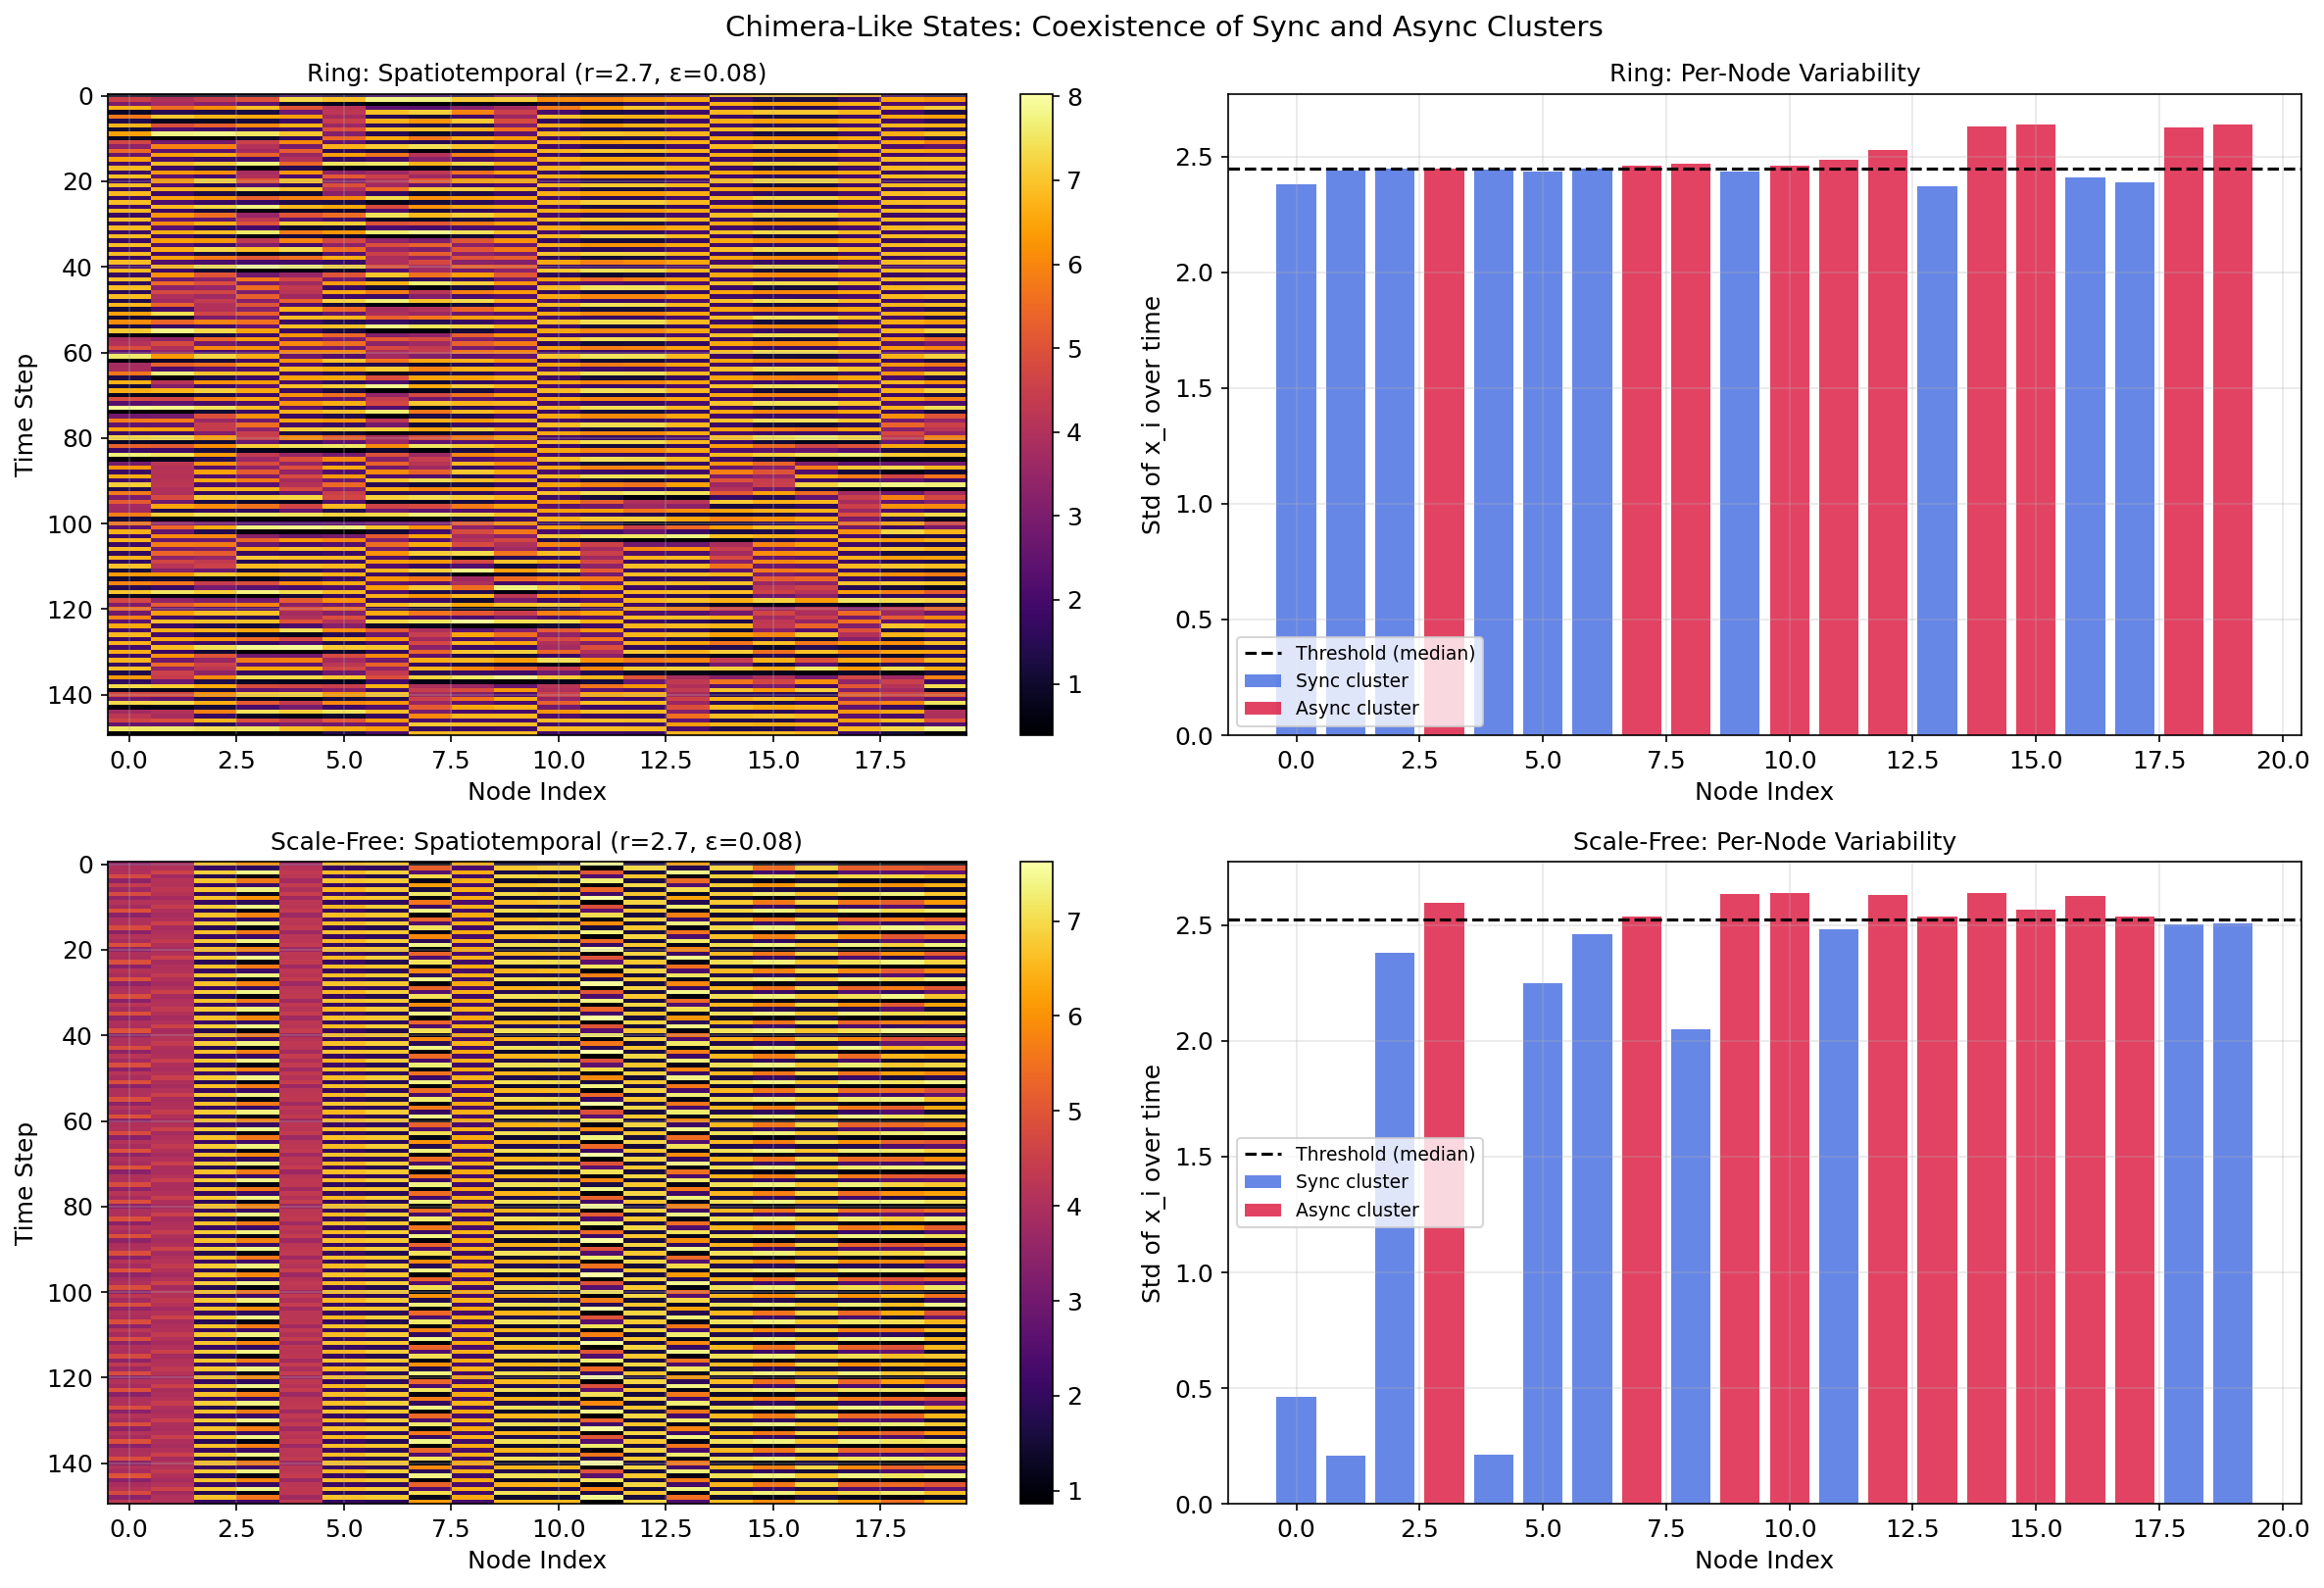

In [12]:


def detect_chimera(G, r, eps, x0, n_steps=800, n_transient=500):
    """
    Detect chimera-like states by measuring per-node variability.
    Nodes with low variance relative to others = synchronized cluster.
    Nodes with high variance = desynchronized / chaotic.
    """
    traj, _ = simulate_cml(G, r, eps, x0, n_steps=n_steps, n_transient=n_transient)
    node_std = np.std(traj, axis=0)  # std of each node over time
    return traj, node_std

# Use ring network at intermediate coupling — known to show chimera
r_chimera = 2.7
eps_chimera = 0.08  # weak coupling — partial sync
np.random.seed(123)
x0_chimera = np.random.uniform(0.5, 3.5, N)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

for ax_spatio, ax_std, (name, G) in zip(
        axes[:, 0], axes[:, 1],
        [('Ring', networks['Ring']), ('Scale-Free', networks['Scale-Free'])]):

    traj, node_std = detect_chimera(G, r_chimera, eps_chimera, x0_chimera)
    threshold = np.median(node_std)
    sync_nodes = np.where(node_std < threshold)[0]
    async_nodes = np.where(node_std >= threshold)[0]

    # Spatiotemporal
    im = ax_spatio.imshow(traj[:150, :], aspect='auto', cmap='inferno',
                          origin='upper', interpolation='nearest')
    ax_spatio.set_title(f'{name}: Spatiotemporal (r={r_chimera}, ε={eps_chimera})', fontsize=12)
    ax_spatio.set_xlabel('Node Index')
    ax_spatio.set_ylabel('Time Step')
    plt.colorbar(im, ax=ax_spatio)

    # Per-node variance
    ax_std.bar(sync_nodes, node_std[sync_nodes], color='royalblue', label='Sync cluster', alpha=0.8)
    ax_std.bar(async_nodes, node_std[async_nodes], color='crimson', label='Async cluster', alpha=0.8)
    ax_std.axhline(threshold, color='k', linestyle='--', label='Threshold (median)')
    ax_std.set_title(f'{name}: Per-Node Variability', fontsize=12)
    ax_std.set_xlabel('Node Index')
    ax_std.set_ylabel('Std of x_i over time')
    ax_std.legend(fontsize=9)

    print(f"{name}: {len(sync_nodes)} synchronized nodes, {len(async_nodes)} asynchronous nodes")

plt.suptitle('Chimera-Like States: Coexistence of Sync and Async Clusters', fontsize=14)
plt.tight_layout()
plt.savefig('chimera_states.png', bbox_inches='tight')
plt.show()

Interpretation:

**1)    The modified Ricker map xn+1=xn2exp⁡(r−xn)x_{n+1} = x_n^2 \exp(r-x_n)
xn+1​=xn2​exp(r−xn​) exhibits a rich local bifurcation structure: a stable fixed point for r≲1.9r \lesssim 1.9
r≲1.9, a period-doubling cascade leading to chaos for r≳2.3r \gtrsim 2.3
r≳2.3, confirmed by a positive Lyapunov exponent.**



**2)  The xn2x_n^2
xn2​ nonlinearity introduces a super-stable point near r=1.3r = 1.3
r=1.3 and produces larger chaotic excursions than the standard Ricker map.**




**3)  When two nodes are coupled, synchronization is non-monotone: weak coupling can transiently increase divergence before strong coupling enforces synchrony — a coupling-induced desynchronization effect most pronounced in the chaotic regime (r=2.8r = 2.8
r=2.8).**





**4)  On networks of 20 nodes, the topology fundamentally shapes collective dynamics. In the chaotic regime (r=2.5r = 2.5
r=2.5, ε=0.15\varepsilon = 0.15
ε=0.15), Random networks achieve the lowest synchronization error (1.07), outperforming Ring (1.65), Scale-Free (1.66), and Small-World (1.84). Scale-Free hubs drive large intermittent bursts visible in spatiotemporal plots, while Ring networks produce coherent traveling wave patterns.**




**5)  Chimera-like states emerge in Scale-Free networks at weak coupling (ε=0.08\varepsilon = 0.08
ε=0.08), where hub nodes synchronize while peripheral nodes remain chaotic — a topologically-induced partial coherence with direct ecological relevance: in a habitat patch network, well-connected patches (nature reserves, large forests) may entrain nearby populations while remote patches fluctuate independently, providing ecological insurance against synchrony-driven global collapse.**